# Assignment algorithm comparison

This notebook compares two families of assignment baselines:

1. **Permissive matching:** local NN, global NN, and Hungarian. Local NN can produce many-to-one matches; global NN resolves those conflicts heuristically.
2. **Strict one-to-one matching:** greedy one-to-one NN, mutual NN, and Hungarian. These let us compare exact and heuristic solvers under the same one-to-one constraint.

The main metrics are link precision/recall/F1, recovered-frame coverage, fragmentation, position error, duplicated GT assignments, high-cost assignments, and runtime.


In [1]:
from pathlib import Path
import os
import sys
import copy
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from helpers.helpersSimulation import Simulator
from helpers.helpersTracking import extract_peaks, track_from_peaks, track_peaks_to_trajectories
from helpers.helpersAssignment import assign_trajectories, compute_cost_matrix_trajectories, TrajToTraj

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


## Experiment settings

The defaults are sized for interactive analysis. Increase `N_SEEDS`, `nparticles`, or `nframes` for final figures. The default uses `mode="detection"` so the assignment comparison runs quickly; switch `TRACKING_KWARGS["mode"]` to `"localization"` if you want the full Gaussian-localization pipeline.


In [2]:
PERMISSIVE_METHODS = ["local_nn", "global_nn", "hungarian"]
STRICT_METHODS = ["greedy_nn", "mutual_nn", "hungarian"]
METHODS = PERMISSIVE_METHODS
METHOD_LABELS = {
    "local_nn": "Local NN",
    "global_nn": "Global NN",
    "hungarian": "Hungarian",
    "greedy_nn": "Greedy 1-to-1 NN",
    "mutual_nn": "Mutual NN",
}
METHOD_COLORS = {
    "local_nn": "#4C78A8",
    "global_nn": "#F58518",
    "hungarian": "#54A24B",
    "greedy_nn": "#E45756",
    "mutual_nn": "#72B7B2",
}

N_SEEDS = 5
SEEDS = list(range(N_SEEDS))
NPOSFRAME_LIST = [2, 4, 6, 8]
POISSON_NOISE_LIST = [100]

SIM_CONFIG_BASE = {
    "nparticles": 12,
    "nframes": 25,
    "nposframe": 4,
    "D_list": [
        (0.10, 0.30),
        (0.50, 0.10),
        (1.50, 0.15),
        (3.50, 0.10),
        (4.00, 0.15),
        (5.00, 0.20),
    ],
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(0), np.deg2rad(0)),
    "frame_size": (128, 128),
    "intensity_mean": 700,
    "intensity_std": 300,
}

IMAGE_CONFIG_BASE = {
    "particle_intensity": [700, 300],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

TRACKING_KWARGS = {
    "mode": "detection",
    "threshold_sigma_below_mean": 1.0,
    "r_squared_threshold": 0.7,
    "max_distance": 2,
    "min_length": 5,
    "max_gap": 0,
    "stitch_fragments": False,
}

ASSIGNMENT_COST_LIMIT = 10.0
EVALUATOR_TRAJ2TRAJ_ALGO = "hungarian"
CANDIDATE_LINKING_ALGO = "hungarian"


## Metric helpers

The link metrics use assigned GT ids only after the evaluation assignment. Using a `Counter` instead of a `set` means duplicate predicted links count as false positives.


In [3]:
def finite_mean(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(np.mean(values)) if len(values) else np.nan


def finite_median(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(np.median(values)) if len(values) else np.nan


def finite_sem(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) <= 1:
        return np.nan
    return float(np.std(values, ddof=1) / np.sqrt(len(values)))


def valid_gt_id(gid, gt_by_id):
    return gid is not None and gid != -1 and gid in gt_by_id


def edge_counter(trajectories, require_valid_gt=True, gt_by_id=None):
    edges = Counter()
    for traj in trajectories:
        gid = traj.id
        if require_valid_gt and not valid_gt_id(gid, gt_by_id):
            continue
        frames = sorted(traj.frames())
        for f0, f1 in zip(frames[:-1], frames[1:]):
            if f1 == f0 + 1:
                edges[(int(gid), int(f0), int(f1))] += 1
    return edges


def precision_recall_f1(pred_edges, gt_edges):
    tp = sum(min(count, gt_edges.get(edge, 0)) for edge, count in pred_edges.items())
    fp = sum(pred_edges.values()) - tp
    fn = sum(gt_edges.values()) - tp

    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
        else np.nan
    )
    return precision, recall, f1, tp, fp, fn


def assigned_position_errors(trajectories, gt_by_id):
    errors = []
    for traj in trajectories:
        if not valid_gt_id(traj.id, gt_by_id):
            continue
        gt_traj = gt_by_id[traj.id]
        for frame in traj.frames():
            pos = traj.get_position_at_frame(frame)
            gt_pos = gt_traj.get_position_at_frame(frame)
            if pos is None or gt_pos is None:
                continue
            errors.append(float(np.linalg.norm(np.asarray(pos) - np.asarray(gt_pos))))
    return np.asarray(errors, dtype=float)


def coverage_and_fragments(trajectories, trajectories_GT):
    gt_by_id = {traj.id: traj for traj in trajectories_GT if traj.id is not None and traj.length() > 0}
    recovered_frames = {gid: set() for gid in gt_by_id}
    fragment_counts = {gid: 0 for gid in gt_by_id}
    assigned_tracks = 0
    unassigned_tracks = 0

    for traj in trajectories:
        if traj.length() == 0:
            continue
        if not valid_gt_id(traj.id, gt_by_id):
            unassigned_tracks += 1
            continue

        assigned_tracks += 1
        fragment_counts[traj.id] += 1
        gt_traj = gt_by_id[traj.id]
        for frame in traj.frames():
            if gt_traj.get_position_at_frame(frame) is not None:
                recovered_frames[traj.id].add(frame)

    coverage = []
    fragments = []
    for gid, gt_traj in gt_by_id.items():
        coverage.append(len(recovered_frames[gid]) / gt_traj.length())
        fragments.append(fragment_counts[gid])

    return {
        "coverage": np.asarray(coverage, dtype=float),
        "fragments": np.asarray(fragments, dtype=float),
        "assigned_tracks": assigned_tracks,
        "unassigned_tracks": unassigned_tracks,
    }


def assignment_diagnostics(assignment, cost_matrix, cost_limit=ASSIGNMENT_COST_LIMIT):
    assignment = list(assignment)
    n_rows, n_cols = cost_matrix.shape if getattr(cost_matrix, "ndim", 0) == 2 else (len(assignment), 0)

    valid_pairs = []
    invalid_count = 0
    for i, j in enumerate(assignment):
        if j is None or int(j) < 0 or int(j) >= n_cols:
            invalid_count += 1
            continue
        valid_pairs.append((i, int(j), float(cost_matrix[i, int(j)])))

    assigned_cols = [j for _, j, _ in valid_pairs]
    duplicate_gt_assignments = sum(count - 1 for count in Counter(assigned_cols).values() if count > 1)
    assigned_costs = np.asarray([cost for _, _, cost in valid_pairs], dtype=float)
    high_cost_assignments = int(np.sum(assigned_costs > cost_limit)) if len(assigned_costs) else 0

    return {
        "n_assignment_rows": n_rows,
        "n_assignment_cols": n_cols,
        "n_assigned_pairs": len(valid_pairs),
        "n_unassigned_rows": invalid_count,
        "duplicate_gt_assignments": duplicate_gt_assignments,
        "high_cost_assignments": high_cost_assignments,
        "assignment_mean_cost": finite_mean(assigned_costs),
        "assignment_median_cost": finite_median(assigned_costs),
    }


def score_labeled_trajectories(
    trajectories,
    trajectories_GT,
    algo,
    seed,
    nposframe,
    poisson_noise,
    stage,
    runtime_s,
    cost_peak2peak=None,
    cost_traj2traj=np.nan,
    extra=None,
):
    gt_by_id = {traj.id: traj for traj in trajectories_GT if traj.id is not None and traj.length() > 0}
    gt_edges = edge_counter(trajectories_GT, require_valid_gt=False)
    pred_edges = edge_counter(trajectories, require_valid_gt=True, gt_by_id=gt_by_id)
    precision, recall, f1, tp, fp, fn = precision_recall_f1(pred_edges, gt_edges)

    cf = coverage_and_fragments(trajectories, trajectories_GT)
    errors = assigned_position_errors(trajectories, gt_by_id)
    n_tracks = sum(traj.length() > 0 for traj in trajectories)
    unassigned_rate = cf["unassigned_tracks"] / n_tracks if n_tracks else np.nan

    cost_peak2peak = [] if cost_peak2peak is None else cost_peak2peak

    row = {
        "stage": stage,
        "algo": algo,
        "algo_label": METHOD_LABELS.get(algo, algo),
        "seed": seed,
        "nposframe": int(nposframe),
        "poisson_noise": poisson_noise,
        "n_gt": len(gt_by_id),
        "n_tracks": n_tracks,
        "assigned_tracks": cf["assigned_tracks"],
        "unassigned_tracks": cf["unassigned_tracks"],
        "unassigned_rate": unassigned_rate,
        "link_precision": precision,
        "link_recall": recall,
        "link_f1": f1,
        "link_tp": tp,
        "link_fp": fp,
        "link_fn": fn,
        "mean_coverage": finite_mean(cf["coverage"]),
        "median_coverage": finite_median(cf["coverage"]),
        "mean_fragments_per_gt": finite_mean(cf["fragments"]),
        "median_fragments_per_gt": finite_median(cf["fragments"]),
        "mean_position_error_px": finite_mean(errors),
        "median_position_error_px": finite_median(errors),
        "runtime_s": float(runtime_s),
        "cost_traj2traj": float(cost_traj2traj) if np.isfinite(cost_traj2traj) else np.nan,
        "mean_cost_peak2peak": finite_mean(cost_peak2peak),
    }

    if extra:
        row.update(extra)
    return row


## Benchmark runners

`run_peak_linking_benchmark` isolates the frame-to-frame assignment by keeping the final GT assignment fixed to Hungarian.

`run_traj_assignment_benchmark` isolates the final GT assignment by creating one candidate track set with a fixed frame-linking algorithm, then reassigning copies of those trajectories with each method.

Use `PERMISSIVE_METHODS` for the local/global NN comparison and `STRICT_METHODS` for the one-to-one comparison with greedy NN, mutual NN, and Hungarian. The same lists can be passed to either runner.


In [4]:
def make_simulation(seed, nposframe, poisson_noise):
    sim_cfg = copy.deepcopy(SIM_CONFIG_BASE)
    sim_cfg["nposframe"] = int(nposframe)

    img_cfg = copy.deepcopy(IMAGE_CONFIG_BASE)
    img_cfg["poisson_noise"] = poisson_noise

    sim = Simulator(sim_cfg, image_config=img_cfg, seed=seed).run()
    return sim, sim_cfg, img_cfg


def detection_threshold_from_config(sim_cfg):
    return sim_cfg["intensity_mean"] - TRACKING_KWARGS["threshold_sigma_below_mean"] * sim_cfg["intensity_std"]


def extract_peaks_once(sim, sim_cfg):
    return extract_peaks(
        sim.frames,
        mode=TRACKING_KWARGS["mode"],
        detection_threshold=detection_threshold_from_config(sim_cfg),
        r_squared_threshold=TRACKING_KWARGS["r_squared_threshold"],
        verbose_loc=False,
        visualization_loc=False,
    )


def peak_count_summary(peaks):
    counts = np.asarray([len(frame_peaks) for frame_peaks in peaks], dtype=float)
    return {
        "total_peaks": int(np.sum(counts)),
        "mean_peaks_per_frame": finite_mean(counts),
        "median_peaks_per_frame": finite_median(counts),
    }


def run_peak_linking_benchmark(
    seeds=SEEDS,
    npos_list=NPOSFRAME_LIST,
    poisson_noise_list=POISSON_NOISE_LIST,
    methods=METHODS,
    evaluator_algo=EVALUATOR_TRAJ2TRAJ_ALGO,
):
    rows = []
    total = len(seeds) * len(npos_list) * len(poisson_noise_list)
    done = 0

    for nposframe in npos_list:
        for poisson_noise in poisson_noise_list:
            for seed in seeds:
                sim, sim_cfg, _ = make_simulation(seed, nposframe, poisson_noise)
                peaks = extract_peaks_once(sim, sim_cfg)
                peak_info = peak_count_summary(peaks)
                done += 1
                print(
                    f"Simulation {done}/{total}: seed={seed}, "
                    f"nposframe={nposframe}, noise={poisson_noise}, "
                    f"peaks={peak_info['total_peaks']}"
                )

                for algo in methods:
                    t0 = time.perf_counter()
                    trajectories, cost_peak2peak, assignment, cost_traj2traj = track_from_peaks(
                        peaks,
                        sim.trajectories_GT,
                        max_distance=TRACKING_KWARGS["max_distance"],
                        min_length=TRACKING_KWARGS["min_length"],
                        max_gap=TRACKING_KWARGS["max_gap"],
                        stitch_fragments=TRACKING_KWARGS["stitch_fragments"],
                        algo_peak2peak=algo,
                        algo_traj2traj=evaluator_algo,
                        verbose_assignment=False,
                    )
                    runtime_s = time.perf_counter() - t0

                    rows.append(
                        score_labeled_trajectories(
                            trajectories=trajectories,
                            trajectories_GT=sim.trajectories_GT,
                            algo=algo,
                            seed=seed,
                            nposframe=nposframe,
                            poisson_noise=poisson_noise,
                            stage="peak2peak",
                            runtime_s=runtime_s,
                            cost_peak2peak=cost_peak2peak,
                            cost_traj2traj=cost_traj2traj,
                            extra={
                                "evaluator_traj2traj_algo": evaluator_algo,
                                "max_distance": TRACKING_KWARGS["max_distance"],
                                **peak_info,
                            },
                        )
                    )

    return pd.DataFrame(rows)


def run_traj_assignment_benchmark(
    seeds=SEEDS,
    npos_list=NPOSFRAME_LIST,
    poisson_noise_list=POISSON_NOISE_LIST,
    methods=METHODS,
    candidate_linking_algo=CANDIDATE_LINKING_ALGO,
):
    rows = []
    total = len(seeds) * len(npos_list) * len(poisson_noise_list)
    done = 0

    for nposframe in npos_list:
        for poisson_noise in poisson_noise_list:
            for seed in seeds:
                sim, sim_cfg, _ = make_simulation(seed, nposframe, poisson_noise)
                peaks = extract_peaks_once(sim, sim_cfg)
                peak_info = peak_count_summary(peaks)

                candidate_tracks, cost_peak2peak = track_peaks_to_trajectories(
                    peaks,
                    max_distance=TRACKING_KWARGS["max_distance"],
                    min_length=TRACKING_KWARGS["min_length"],
                    algorithm=candidate_linking_algo,
                    max_gap=TRACKING_KWARGS["max_gap"],
                )

                done += 1
                print(
                    f"Candidate set {done}/{total}: seed={seed}, "
                    f"nposframe={nposframe}, noise={poisson_noise}, "
                    f"tracks={len(candidate_tracks)}"
                )

                cost_function = TrajToTraj.default()
                base_cost_matrix = compute_cost_matrix_trajectories(
                    candidate_tracks,
                    sim.trajectories_GT,
                    cost_function=cost_function,
                ) if len(candidate_tracks) else np.zeros((0, len(sim.trajectories_GT)))

                for algo in methods:
                    tracks_for_assignment = copy.deepcopy(candidate_tracks)
                    t0 = time.perf_counter()
                    assigned_tracks, cost_traj2traj, assignment = assign_trajectories(
                        tracks_for_assignment,
                        sim.trajectories_GT,
                        algorithm=algo,
                        cost_function=cost_function,
                        verbose=False,
                    )
                    runtime_s = time.perf_counter() - t0

                    diagnostics = assignment_diagnostics(
                        assignment,
                        base_cost_matrix,
                        cost_limit=ASSIGNMENT_COST_LIMIT,
                    )

                    rows.append(
                        score_labeled_trajectories(
                            trajectories=assigned_tracks,
                            trajectories_GT=sim.trajectories_GT,
                            algo=algo,
                            seed=seed,
                            nposframe=nposframe,
                            poisson_noise=poisson_noise,
                            stage="traj2traj",
                            runtime_s=runtime_s,
                            cost_peak2peak=cost_peak2peak,
                            cost_traj2traj=cost_traj2traj,
                            extra={
                                "candidate_linking_algo": candidate_linking_algo,
                                "max_distance": TRACKING_KWARGS["max_distance"],
                                **peak_info,
                                **diagnostics,
                            },
                        )
                    )

    return pd.DataFrame(rows)


## Plotting and summary helpers


In [5]:
def summarize_metrics(df, group_cols, metrics):
    rows = []
    for keys, group in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row["n"] = len(group)
        for metric in metrics:
            values = group[metric].to_numpy(dtype=float)
            row[f"{metric}_mean"] = finite_mean(values)
            row[f"{metric}_ci95"] = 1.96 * finite_sem(values)
        rows.append(row)
    return pd.DataFrame(rows)


def plot_metric_vs_density(df, metric, ylabel=None, title=None, ylim=None, methods=None):
    methods = METHODS if methods is None else methods
    plt.figure(figsize=(8, 5))
    for algo in methods:
        subset = df[df["algo"] == algo]
        grouped = subset.groupby("nposframe")[metric]
        mean = grouped.mean()
        ci95 = 1.96 * grouped.sem()
        x = mean.index.to_numpy(dtype=float)
        y = mean.to_numpy(dtype=float)
        e = ci95.fillna(0).to_numpy(dtype=float)

        plt.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            color=METHOD_COLORS[algo],
            label=METHOD_LABELS[algo],
        )
        plt.fill_between(x, y - e, y + e, color=METHOD_COLORS[algo], alpha=0.18)

    plt.xlabel("Sub-positions per frame (motion/density difficulty)")
    plt.ylabel(ylabel or metric)
    if title:
        plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_speed_accuracy(df, metric="link_f1", nposframe=None, methods=None):
    methods = METHODS if methods is None else methods
    if nposframe is None:
        nposframe = int(df["nposframe"].max())

    subset = df[df["nposframe"] == nposframe]
    points = (
        subset[subset["algo"].isin(methods)]
        .groupby("algo")[["runtime_s", metric]]
        .mean()
        .reindex(methods)
        .reset_index()
    )

    plt.figure(figsize=(6, 5))
    for _, row in points.iterrows():
        algo = row["algo"]
        if algo not in METHOD_COLORS:
            continue
        plt.scatter(
            row["runtime_s"],
            row[metric],
            s=100,
            color=METHOD_COLORS[algo],
            label=METHOD_LABELS[algo],
        )
        plt.text(row["runtime_s"], row[metric], f"  {METHOD_LABELS[algo]}", va="center")

    plt.xlabel("Mean runtime (s)")
    plt.ylabel(metric)
    plt.title(f"Speed vs {metric} at nposframe={nposframe}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_metric_distribution(df, metric, ylabel=None, title=None, methods=None):
    methods = METHODS if methods is None else methods
    data = [df[df["algo"] == algo][metric].dropna().to_numpy(dtype=float) for algo in methods]
    labels = [METHOD_LABELS[algo] for algo in methods]

    plt.figure(figsize=(7, 5))
    bp = plt.boxplot(data, labels=labels, showfliers=False, patch_artist=True)
    for patch, algo in zip(bp["boxes"], methods):
        patch.set_facecolor(METHOD_COLORS[algo])
        patch.set_alpha(0.25)
        patch.set_edgecolor(METHOD_COLORS[algo])
    plt.ylabel(ylabel or metric)
    if title:
        plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def paired_delta_table(df, metric, baseline="hungarian", methods=None):
    methods = METHODS if methods is None else methods
    index_cols = ["seed", "nposframe", "poisson_noise"]
    wide = df.pivot_table(index=index_cols, columns="algo", values=metric, aggfunc="mean")
    deltas = pd.DataFrame(index=wide.index)
    for algo in methods:
        if algo == baseline or algo not in wide or baseline not in wide:
            continue
        deltas[f"{algo}_minus_{baseline}"] = wide[algo] - wide[baseline]
    return deltas.reset_index()


## 1. Peak-to-peak assignment comparison

Only `algo_peak2peak` changes here. The final trajectory-to-GT assignment is fixed to Hungarian so the metrics compare the frame-linking algorithm rather than the evaluation labels.


In [6]:
peak_df = run_peak_linking_benchmark()
peak_df.head()


Simulation 1/20: seed=0, nposframe=2, noise=100, peaks=321
Simulation 2/20: seed=1, nposframe=2, noise=100, peaks=302
Simulation 3/20: seed=2, nposframe=2, noise=100, peaks=310
Simulation 4/20: seed=3, nposframe=2, noise=100, peaks=293
Simulation 5/20: seed=4, nposframe=2, noise=100, peaks=300
Simulation 6/20: seed=0, nposframe=4, noise=100, peaks=350
Simulation 7/20: seed=1, nposframe=4, noise=100, peaks=330
Simulation 8/20: seed=2, nposframe=4, noise=100, peaks=337
Simulation 9/20: seed=3, nposframe=4, noise=100, peaks=311
Simulation 10/20: seed=4, nposframe=4, noise=100, peaks=355
Simulation 11/20: seed=0, nposframe=6, noise=100, peaks=341
Simulation 12/20: seed=1, nposframe=6, noise=100, peaks=332
Simulation 13/20: seed=2, nposframe=6, noise=100, peaks=336
Simulation 14/20: seed=3, nposframe=6, noise=100, peaks=332
Simulation 15/20: seed=4, nposframe=6, noise=100, peaks=338
Simulation 16/20: seed=0, nposframe=8, noise=100, peaks=342
Simulation 17/20: seed=1, nposframe=8, noise=100,

,stage,algo,algo_label,seed,nposframe,poisson_noise,n_gt,n_tracks,assigned_tracks,unassigned_tracks,...,mean_position_error_px,median_position_error_px,runtime_s,cost_traj2traj,mean_cost_peak2peak,evaluator_traj2traj_algo,max_distance,total_peaks,mean_peaks_per_frame,median_peaks_per_frame
0,peak2peak,local_nn,Local NN,0,2,100,12,9,9,0,...,13.100094,7.677675,0.064957,87.345789,9.143511e-01,hungarian,2,321,12.84,13.0
1,peak2peak,global_nn,Global NN,0,2,100,12,8,8,0,...,4.976885,1.219404,0.050135,47.869695,8.272144e-01,hungarian,2,321,12.84,13.0
2,peak2peak,hungarian,Hungarian,0,2,100,12,8,8,0,...,4.976885,1.219404,0.070424,47.869695,5.916667e+06,hungarian,2,321,12.84,13.0
3,peak2peak,local_nn,Local NN,1,2,100,12,18,12,6,...,4.639189,0.926820,0.106188,64.992842,1.448282e+00,hungarian,2,302,12.08,12.0
4,peak2peak,global_nn,Global NN,1,2,100,12,14,12,2,...,6.511373,0.863811,0.073087,118.774460,1.168892e+00,hungarian,2,302,12.08,12.0


In [7]:
def make_simulation(seed, nposframe, poisson_noise):
    sim_cfg = copy.deepcopy(SIM_CONFIG_BASE)
    sim_cfg["nposframe"] = int(nposframe)

    img_cfg = copy.deepcopy(IMAGE_CONFIG_BASE)
    img_cfg["poisson_noise"] = poisson_noise

    sim = Simulator(sim_cfg, image_config=img_cfg, seed=seed).run()
    return sim, sim_cfg, img_cfg


def detection_threshold_from_config(sim_cfg):
    return sim_cfg["intensity_mean"] - TRACKING_KWARGS["threshold_sigma_below_mean"] * sim_cfg["intensity_std"]


def extract_peaks_once(sim, sim_cfg):
    return extract_peaks(
        sim.frames,
        mode=TRACKING_KWARGS["mode"],
        detection_threshold=detection_threshold_from_config(sim_cfg),
        r_squared_threshold=TRACKING_KWARGS["r_squared_threshold"],
        verbose_loc=False,
        visualization_loc=False,
    )


def peak_count_summary(peaks):
    counts = np.asarray([len(frame_peaks) for frame_peaks in peaks], dtype=float)
    return {
        "total_peaks": int(np.sum(counts)),
        "mean_peaks_per_frame": finite_mean(counts),
        "median_peaks_per_frame": finite_median(counts),
    }


def run_peak_linking_benchmark(
    seeds=SEEDS,
    npos_list=NPOSFRAME_LIST,
    poisson_noise_list=POISSON_NOISE_LIST,
    methods=METHODS,
    evaluator_algo=EVALUATOR_TRAJ2TRAJ_ALGO,
):
    rows = []
    total = len(seeds) * len(npos_list) * len(poisson_noise_list)
    done = 0

    for nposframe in npos_list:
        for poisson_noise in poisson_noise_list:
            for seed in seeds:
                sim, sim_cfg, _ = make_simulation(seed, nposframe, poisson_noise)
                peaks = extract_peaks_once(sim, sim_cfg)
                peak_info = peak_count_summary(peaks)
                done += 1
                print(
                    f"Simulation {done}/{total}: seed={seed}, "
                    f"nposframe={nposframe}, noise={poisson_noise}, "
                    f"peaks={peak_info['total_peaks']}"
                )

                for algo in methods:
                    t0 = time.perf_counter()
                    trajectories, cost_peak2peak, assignment, cost_traj2traj = track_from_peaks(
                        peaks,
                        sim.trajectories_GT,
                        max_distance=TRACKING_KWARGS["max_distance"],
                        min_length=TRACKING_KWARGS["min_length"],
                        max_gap=TRACKING_KWARGS["max_gap"],
                        stitch_fragments=TRACKING_KWARGS["stitch_fragments"],
                        algo_peak2peak=algo,
                        algo_traj2traj=evaluator_algo,
                        verbose_assignment=False,
                    )
                    runtime_s = time.perf_counter() - t0

                    rows.append(
                        score_labeled_trajectories(
                            trajectories=trajectories,
                            trajectories_GT=sim.trajectories_GT,
                            algo=algo,
                            seed=seed,
                            nposframe=nposframe,
                            poisson_noise=poisson_noise,
                            stage="peak2peak",
                            runtime_s=runtime_s,
                            cost_peak2peak=cost_peak2peak,
                            cost_traj2traj=cost_traj2traj,
                            extra={
                                "evaluator_traj2traj_algo": evaluator_algo,
                                "max_distance": TRACKING_KWARGS["max_distance"],
                                **peak_info,
                            },
                        )
                    )

    return pd.DataFrame(rows)


def run_traj_assignment_benchmark(
    seeds=SEEDS,
    npos_list=NPOSFRAME_LIST,
    poisson_noise_list=POISSON_NOISE_LIST,
    methods=METHODS,
    candidate_linking_algo=CANDIDATE_LINKING_ALGO,
):
    rows = []
    total = len(seeds) * len(npos_list) * len(poisson_noise_list)
    done = 0

    for nposframe in npos_list:
        for poisson_noise in poisson_noise_list:
            for seed in seeds:
                sim, sim_cfg, _ = make_simulation(seed, nposframe, poisson_noise)
                peaks = extract_peaks_once(sim, sim_cfg)
                peak_info = peak_count_summary(peaks)

                candidate_tracks, cost_peak2peak = track_peaks_to_trajectories(
                    peaks,
                    max_distance=TRACKING_KWARGS["max_distance"],
                    min_length=TRACKING_KWARGS["min_length"],
                    algorithm=candidate_linking_algo,
                    max_gap=TRACKING_KWARGS["max_gap"],
                )

                done += 1
                print(
                    f"Candidate set {done}/{total}: seed={seed}, "
                    f"nposframe={nposframe}, noise={poisson_noise}, "
                    f"tracks={len(candidate_tracks)}"
                )

                cost_function = TrajToTraj.default()
                base_cost_matrix = compute_cost_matrix_trajectories(
                    candidate_tracks,
                    sim.trajectories_GT,
                    cost_function=cost_function,
                ) if len(candidate_tracks) else np.zeros((0, len(sim.trajectories_GT)))

                for algo in methods:
                    tracks_for_assignment = copy.deepcopy(candidate_tracks)
                    t0 = time.perf_counter()
                    assigned_tracks, cost_traj2traj, assignment = assign_trajectories(
                        tracks_for_assignment,
                        sim.trajectories_GT,
                        algorithm=algo,
                        cost_function=cost_function,
                        verbose=False,
                    )
                    runtime_s = time.perf_counter() - t0

                    diagnostics = assignment_diagnostics(
                        assignment,
                        base_cost_matrix,
                        cost_limit=ASSIGNMENT_COST_LIMIT,
                    )

                    rows.append(
                        score_labeled_trajectories(
                            trajectories=assigned_tracks,
                            trajectories_GT=sim.trajectories_GT,
                            algo=algo,
                            seed=seed,
                            nposframe=nposframe,
                            poisson_noise=poisson_noise,
                            stage="traj2traj",
                            runtime_s=runtime_s,
                            cost_peak2peak=cost_peak2peak,
                            cost_traj2traj=cost_traj2traj,
                            extra={
                                "candidate_linking_algo": candidate_linking_algo,
                                "max_distance": TRACKING_KWARGS["max_distance"],
                                **peak_info,
                                **diagnostics,
                            },
                        )
                    )

    return pd.DataFrame(rows)


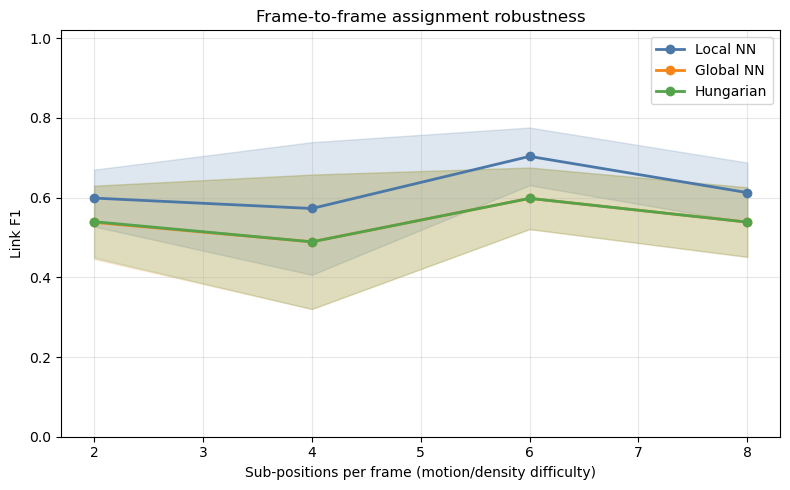

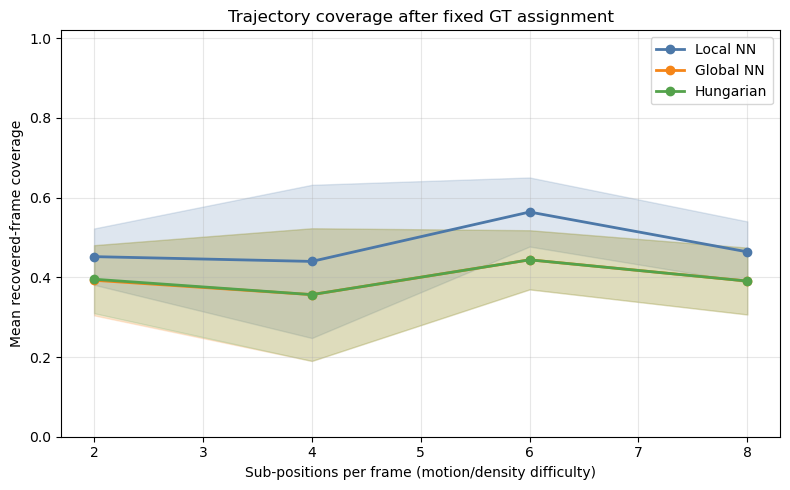

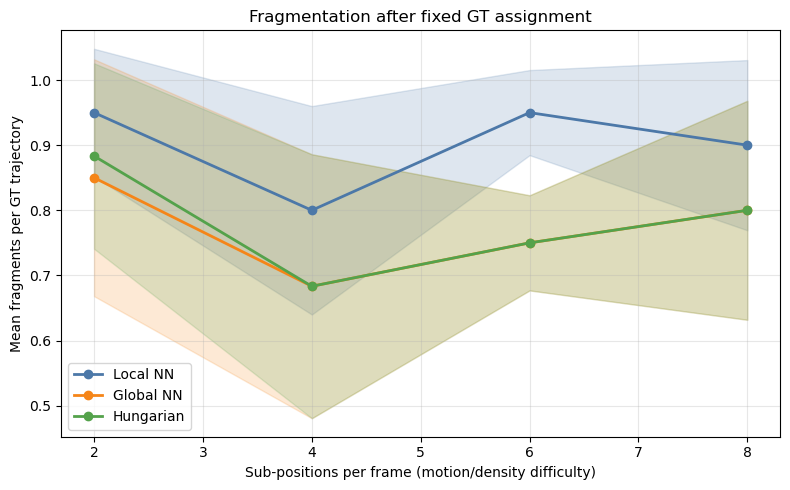

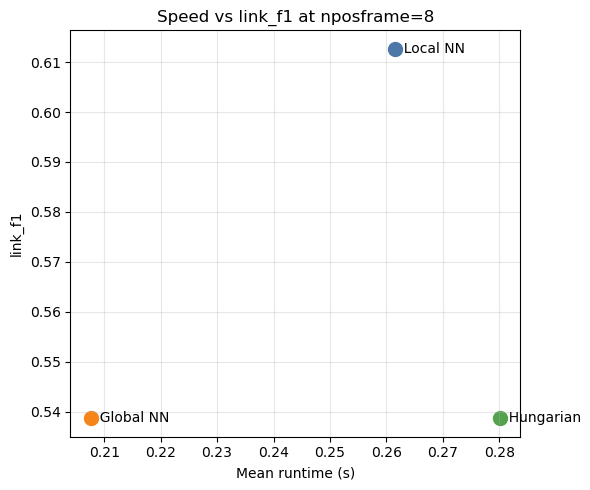

In [8]:
plot_metric_vs_density(
    peak_df,
    "link_f1",
    ylabel="Link F1",
    title="Frame-to-frame assignment robustness",
    ylim=(0, 1.02),
)

plot_metric_vs_density(
    peak_df,
    "mean_coverage",
    ylabel="Mean recovered-frame coverage",
    title="Trajectory coverage after fixed GT assignment",
    ylim=(0, 1.02),
)

plot_metric_vs_density(
    peak_df,
    "mean_fragments_per_gt",
    ylabel="Mean fragments per GT trajectory",
    title="Fragmentation after fixed GT assignment",
)

plot_speed_accuracy(peak_df, metric="link_f1")


In [9]:
link_f1_delta = paired_delta_table(peak_df, "link_f1", baseline="hungarian")
coverage_delta = paired_delta_table(peak_df, "mean_coverage", baseline="hungarian")

print("Mean paired Link-F1 delta against Hungarian. Positive means the method beat Hungarian on the same simulation.")
display(link_f1_delta.drop(columns=["seed", "nposframe", "poisson_noise"]).mean().round(4))

print("Mean paired coverage delta against Hungarian.")
display(coverage_delta.drop(columns=["seed", "nposframe", "poisson_noise"]).mean().round(4))


Mean paired Link-F1 delta against Hungarian. Positive means the method beat Hungarian on the same simulation.


local_nn_minus_hungarian     0.0806
global_nn_minus_hungarian   -0.0004
dtype: float64

Mean paired coverage delta against Hungarian.


local_nn_minus_hungarian     0.0833
global_nn_minus_hungarian   -0.0007
dtype: float64

## 2. Trajectory-to-trajectory assignment comparison

The candidate trajectories are generated once with `CANDIDATE_LINKING_ALGO`. Only the final assignment of those same trajectories to ground truth changes.

For this stage, watch `duplicate_gt_assignments` and `high_cost_assignments`: Local NN can assign several tracks to the same GT trajectory, while Hungarian can force assignments when all available costs are bad.


In [10]:
assignment_df = run_traj_assignment_benchmark()
assignment_df.head()


Candidate set 1/20: seed=0, nposframe=2, noise=100, tracks=8
Candidate set 2/20: seed=1, nposframe=2, noise=100, tracks=14
Candidate set 3/20: seed=2, nposframe=2, noise=100, tracks=9
Candidate set 4/20: seed=3, nposframe=2, noise=100, tracks=14
Candidate set 5/20: seed=4, nposframe=2, noise=100, tracks=17
Candidate set 6/20: seed=0, nposframe=4, noise=100, tracks=5
Candidate set 7/20: seed=1, nposframe=4, noise=100, tracks=11
Candidate set 8/20: seed=2, nposframe=4, noise=100, tracks=6
Candidate set 9/20: seed=3, nposframe=4, noise=100, tracks=11
Candidate set 10/20: seed=4, nposframe=4, noise=100, tracks=8
Candidate set 11/20: seed=0, nposframe=6, noise=100, tracks=9
Candidate set 12/20: seed=1, nposframe=6, noise=100, tracks=10
Candidate set 13/20: seed=2, nposframe=6, noise=100, tracks=10
Candidate set 14/20: seed=3, nposframe=6, noise=100, tracks=8
Candidate set 15/20: seed=4, nposframe=6, noise=100, tracks=8
Candidate set 16/20: seed=0, nposframe=8, noise=100, tracks=7
Candidate 

,stage,algo,algo_label,seed,nposframe,poisson_noise,n_gt,n_tracks,assigned_tracks,unassigned_tracks,...,mean_peaks_per_frame,median_peaks_per_frame,n_assignment_rows,n_assignment_cols,n_assigned_pairs,n_unassigned_rows,duplicate_gt_assignments,high_cost_assignments,assignment_mean_cost,assignment_median_cost
0,traj2traj,local_nn,Local NN,0,2,100,12,8,8,0,...,12.84,13.0,8,12,8,0,3,0,0.919838,0.883076
1,traj2traj,global_nn,Global NN,0,2,100,12,8,5,3,...,12.84,13.0,8,12,5,3,0,0,0.912206,0.829344
2,traj2traj,hungarian,Hungarian,0,2,100,12,8,8,0,...,12.84,13.0,8,12,8,0,0,3,5.983712,3.569111
3,traj2traj,local_nn,Local NN,1,2,100,12,14,14,0,...,12.08,12.0,14,12,14,0,6,0,0.880414,0.840395
4,traj2traj,global_nn,Global NN,1,2,100,12,14,8,6,...,12.08,12.0,14,12,8,6,0,0,0.799334,0.795560


In [11]:
assignment_metrics = [
    "link_f1",
    "mean_coverage",
    "mean_fragments_per_gt",
    "median_position_error_px",
    "duplicate_gt_assignments",
    "high_cost_assignments",
    "assignment_median_cost",
    "runtime_s",
]

assignment_summary = summarize_metrics(
    assignment_df,
    group_cols=["nposframe", "algo", "algo_label"],
    metrics=assignment_metrics,
)

display(
    assignment_df.pivot_table(
        index="nposframe",
        columns="algo_label",
        values="link_f1",
        aggfunc="mean",
    ).round(3)
)

display(
    assignment_summary.sort_values(["nposframe", "algo"])
    .round(4)
    .reset_index(drop=True)
)


algo_label,Global NN,Hungarian,Local NN
nposframe,,,
2,0.439,0.540,0.574
4,0.395,0.489,0.489
6,0.532,0.598,0.598
8,0.474,0.539,0.570


,nposframe,algo,algo_label,n,link_f1_mean,link_f1_ci95,mean_coverage_mean,mean_coverage_ci95,mean_fragments_per_gt_mean,mean_fragments_per_gt_ci95,median_position_error_px_mean,median_position_error_px_ci95,duplicate_gt_assignments_mean,duplicate_gt_assignments_ci95,high_cost_assignments_mean,high_cost_assignments_ci95,assignment_median_cost_mean,assignment_median_cost_ci95,runtime_s_mean,runtime_s_ci95
0,2,global_nn,Global NN,5,0.4394,0.1176,0.3020,0.0967,0.6167,0.1682,0.7811,0.0608,0.0,0.0000,0.0,0.0000,0.7856,0.0542,0.1107,0.0549
1,2,hungarian,Hungarian,5,0.5398,0.0902,0.3953,0.0854,0.8833,0.1424,1.0127,0.1719,0.0,0.0000,2.8,0.3920,1.6899,1.0420,0.1061,0.0348
2,2,local_nn,Local NN,5,0.5736,0.1256,0.4367,0.1300,1.0333,0.2762,0.8132,0.0325,5.0,1.3859,0.0,0.0000,0.8529,0.0278,0.1186,0.0632
3,4,global_nn,Global NN,5,0.3950,0.1886,0.2753,0.1679,0.4833,0.1584,0.8802,0.0922,0.0,0.0000,0.0,0.0000,0.9299,0.1217,0.0734,0.0285
4,4,hungarian,Hungarian,5,0.4892,0.1687,0.3567,0.1665,0.6833,0.2027,4.5884,6.7877,0.0,0.0000,2.6,1.5923,4.9936,7.6345,0.0751,0.0187
5,4,local_nn,Local NN,5,0.4892,0.1687,0.3547,0.1662,0.6833,0.2027,0.8721,0.0618,2.4,1.3293,0.0,0.0000,0.9518,0.0681,0.0897,0.0494
6,6,global_nn,Global NN,5,0.5317,0.0942,0.3767,0.0854,0.5833,0.0000,0.7900,0.0261,0.0,0.0000,0.0,0.0000,0.8551,0.0958,0.1010,0.0463
7,6,hungarian,Hungarian,5,0.5983,0.0773,0.4440,0.0742,0.7500,0.0730,0.9406,0.0644,0.0,0.0000,1.6,1.1760,1.1308,0.2200,0.1041,0.0450
8,6,local_nn,Local NN,5,0.5983,0.0773,0.4427,0.0754,0.7500,0.0730,0.8013,0.0380,2.0,0.8765,0.0,0.0000,0.8674,0.0639,0.0962,0.0312
9,8,global_nn,Global NN,5,0.4736,0.0921,0.3280,0.0824,0.6333,0.1327,0.8146,0.0540,0.0,0.0000,0.0,0.0000,0.8694,0.1015,0.0979,0.0538


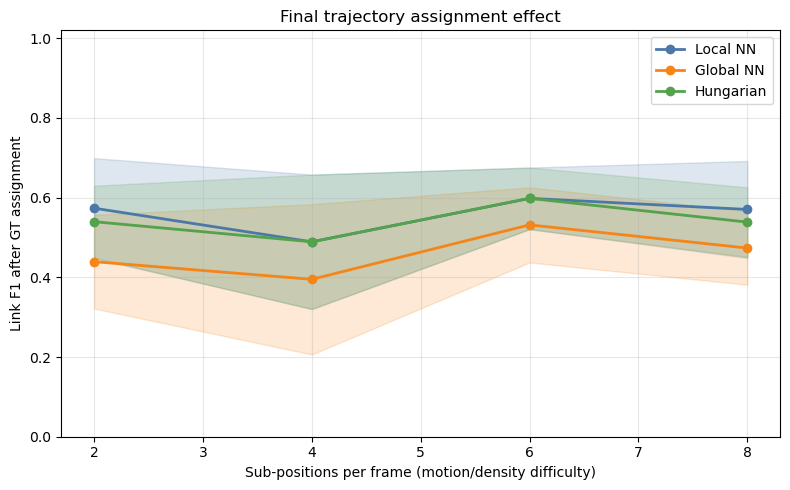

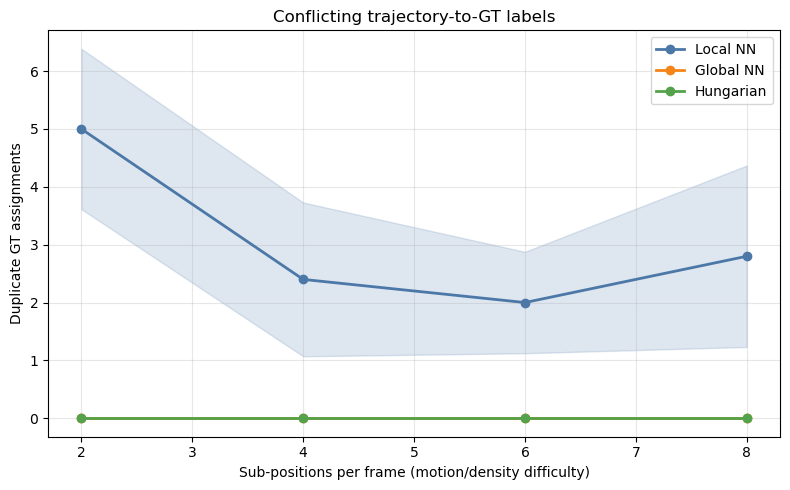

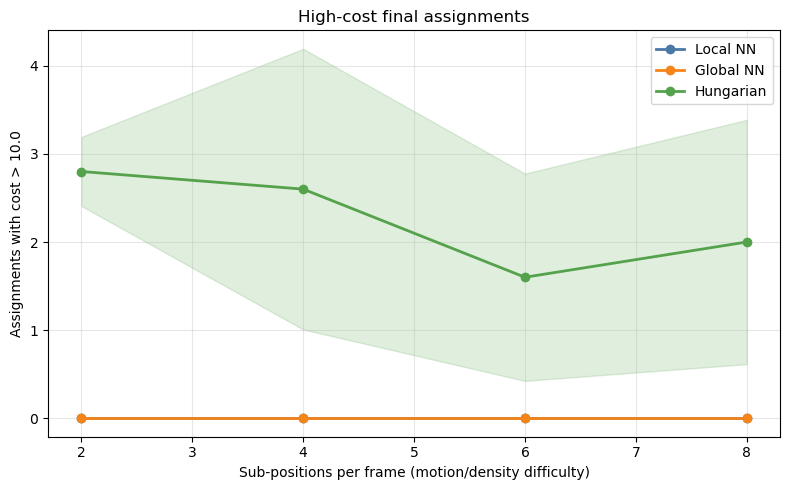

C:\Users\armel\AppData\Local\Temp\ipykernel_37144\3482098473.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=labels, showfliers=False, patch_artist=True)


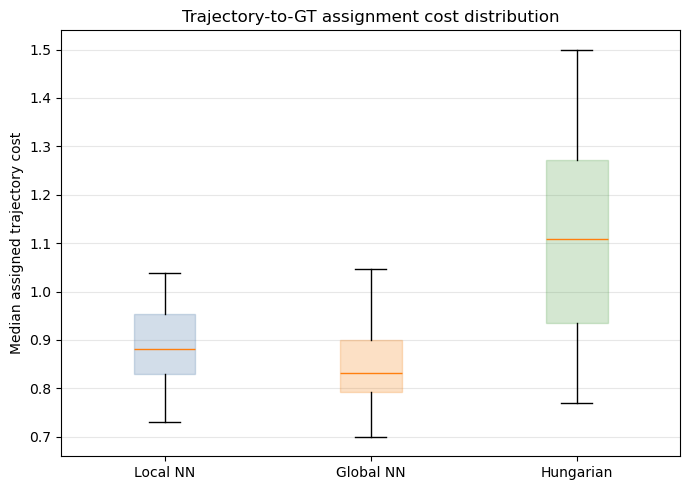

In [12]:
plot_metric_vs_density(
    assignment_df,
    "link_f1",
    ylabel="Link F1 after GT assignment",
    title="Final trajectory assignment effect",
    ylim=(0, 1.02),
)

plot_metric_vs_density(
    assignment_df,
    "duplicate_gt_assignments",
    ylabel="Duplicate GT assignments",
    title="Conflicting trajectory-to-GT labels",
)

plot_metric_vs_density(
    assignment_df,
    "high_cost_assignments",
    ylabel=f"Assignments with cost > {ASSIGNMENT_COST_LIMIT}",
    title="High-cost final assignments",
)

plot_metric_distribution(
    assignment_df,
    "assignment_median_cost",
    ylabel="Median assigned trajectory cost",
    title="Trajectory-to-GT assignment cost distribution",
)


## Interpretation checklist

A sensible winner is not just the algorithm with the lowest cost. Prefer the method that keeps high link F1 and coverage while avoiding many fragments, duplicate GT labels, high-cost GT assignments, and excessive runtime.

Useful reads:

- If `local_nn` has good recall but many duplicate GT assignments, it is over-linking conflicts.
- If `global_nn` loses recall but reduces duplicates, it is resolving conflicts conservatively.
- If `hungarian` has high coverage but many high-cost final assignments, add explicit gating before the final assignment or treat costs above `ASSIGNMENT_COST_LIMIT` as unassigned.


## 3. Strict one-to-one assignment comparison

This section reuses the same candidate trajectories and compares Hungarian against the two heuristic one-to-one baselines: greedy NN and mutual NN. Use it when you want to argue about exact one-to-one optimization rather than permissive many-to-one matching. If you want the same strict comparison for frame-to-frame linking, pass `STRICT_METHODS` to `run_peak_linking_benchmark`.


In [13]:
strict_df = run_traj_assignment_benchmark(
    methods=STRICT_METHODS,
    candidate_linking_algo=CANDIDATE_LINKING_ALGO,
)
strict_df.head()


Candidate set 1/20: seed=0, nposframe=2, noise=100, tracks=8
Candidate set 2/20: seed=1, nposframe=2, noise=100, tracks=14
Candidate set 3/20: seed=2, nposframe=2, noise=100, tracks=9
Candidate set 4/20: seed=3, nposframe=2, noise=100, tracks=14
Candidate set 5/20: seed=4, nposframe=2, noise=100, tracks=17
Candidate set 6/20: seed=0, nposframe=4, noise=100, tracks=5
Candidate set 7/20: seed=1, nposframe=4, noise=100, tracks=11
Candidate set 8/20: seed=2, nposframe=4, noise=100, tracks=6
Candidate set 9/20: seed=3, nposframe=4, noise=100, tracks=11
Candidate set 10/20: seed=4, nposframe=4, noise=100, tracks=8
Candidate set 11/20: seed=0, nposframe=6, noise=100, tracks=9
Candidate set 12/20: seed=1, nposframe=6, noise=100, tracks=10
Candidate set 13/20: seed=2, nposframe=6, noise=100, tracks=10
Candidate set 14/20: seed=3, nposframe=6, noise=100, tracks=8
Candidate set 15/20: seed=4, nposframe=6, noise=100, tracks=8
Candidate set 16/20: seed=0, nposframe=8, noise=100, tracks=7
Candidate 

,stage,algo,algo_label,seed,nposframe,poisson_noise,n_gt,n_tracks,assigned_tracks,unassigned_tracks,...,mean_peaks_per_frame,median_peaks_per_frame,n_assignment_rows,n_assignment_cols,n_assigned_pairs,n_unassigned_rows,duplicate_gt_assignments,high_cost_assignments,assignment_mean_cost,assignment_median_cost
0,traj2traj,greedy_nn,Greedy 1-to-1 NN,0,2,100,12,8,6,2,...,12.84,13.0,8,12,6,2,0,0,2.003790,0.928953
1,traj2traj,mutual_nn,Mutual NN,0,2,100,12,8,6,2,...,12.84,13.0,8,12,6,2,0,0,2.003790,0.928953
2,traj2traj,hungarian,Hungarian,0,2,100,12,8,8,0,...,12.84,13.0,8,12,8,0,0,3,5.983712,3.569111
3,traj2traj,greedy_nn,Greedy 1-to-1 NN,1,2,100,12,14,9,5,...,12.08,12.0,14,12,9,5,0,0,0.953783,0.798958
4,traj2traj,mutual_nn,Mutual NN,1,2,100,12,14,9,5,...,12.08,12.0,14,12,9,5,0,0,0.953783,0.798958


algo_label,Greedy 1-to-1 NN,Hungarian,Mutual NN
nposframe,,,
2,0.463,0.540,0.463
4,0.395,0.489,0.395
6,0.546,0.598,0.546
8,0.484,0.539,0.484


algo_label,Greedy 1-to-1 NN,Hungarian,Mutual NN
nposframe,,,
2,0.810,1.690,0.810
4,0.930,4.994,0.930
6,0.870,1.131,0.870
8,0.882,1.102,0.882


,nposframe,algo,algo_label,n,link_f1_mean,link_f1_ci95,link_precision_mean,link_precision_ci95,link_recall_mean,link_recall_ci95,...,duplicate_gt_assignments_mean,duplicate_gt_assignments_ci95,high_cost_assignments_mean,high_cost_assignments_ci95,assignment_mean_cost_mean,assignment_mean_cost_ci95,assignment_median_cost_mean,assignment_median_cost_ci95,runtime_s_mean,runtime_s_ci95
0,2,greedy_nn,Greedy 1-to-1 NN,5,0.4629,0.0952,1.0,0.0,0.3062,0.0796,...,0.0,0.0,0.0,0.0000,1.2335,0.4217,0.8098,0.0807,0.0861,0.0377
1,2,hungarian,Hungarian,5,0.5398,0.0902,1.0,0.0,0.3750,0.0831,...,0.0,0.0,2.8,0.3920,7.4913,2.4224,1.6899,1.0420,0.0955,0.0479
2,2,mutual_nn,Mutual NN,5,0.4629,0.0952,1.0,0.0,0.3062,0.0796,...,0.0,0.0,0.0,0.0000,1.2335,0.4217,0.8098,0.0807,0.0942,0.0408
3,4,greedy_nn,Greedy 1-to-1 NN,5,0.3950,0.1886,1.0,0.0,0.2667,0.1686,...,0.0,0.0,0.0,0.0000,1.1269,0.2196,0.9299,0.1217,0.0840,0.0466
4,4,hungarian,Hungarian,5,0.4892,0.1687,1.0,0.0,0.3431,0.1665,...,0.0,0.0,2.6,1.5923,9.2445,4.9220,4.9936,7.6345,0.0812,0.0346
5,4,mutual_nn,Mutual NN,5,0.3950,0.1886,1.0,0.0,0.2667,0.1686,...,0.0,0.0,0.0,0.0000,1.1269,0.2196,0.9299,0.1217,0.0891,0.0523
6,6,greedy_nn,Greedy 1-to-1 NN,5,0.5461,0.0845,1.0,0.0,0.3806,0.0821,...,0.0,0.0,0.0,0.0000,1.3870,0.4381,0.8701,0.1167,0.0635,0.0396
7,6,hungarian,Hungarian,5,0.5983,0.0773,1.0,0.0,0.4312,0.0772,...,0.0,0.0,1.6,1.1760,6.8279,4.1282,1.1308,0.2200,0.0659,0.0417
8,6,mutual_nn,Mutual NN,5,0.5461,0.0845,1.0,0.0,0.3806,0.0821,...,0.0,0.0,0.0,0.0000,1.3870,0.4381,0.8701,0.1167,0.0597,0.0322
9,8,greedy_nn,Greedy 1-to-1 NN,5,0.4835,0.0888,1.0,0.0,0.3236,0.0781,...,0.0,0.0,0.0,0.0000,1.4169,0.3853,0.8820,0.0884,0.1127,0.0555


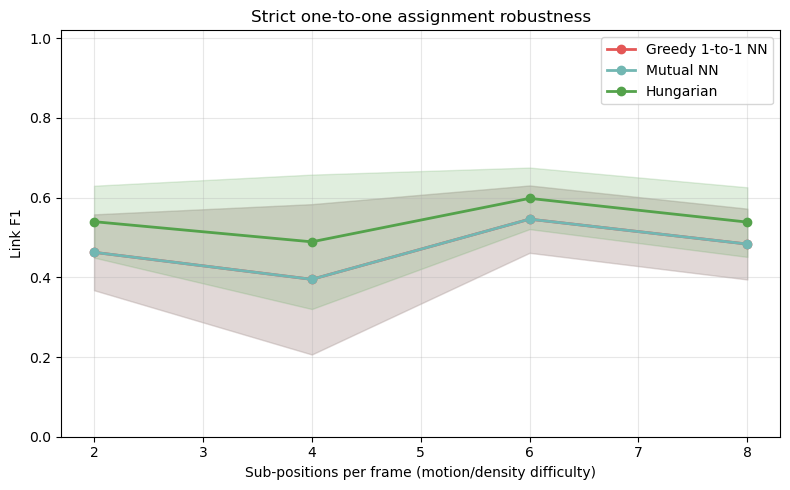

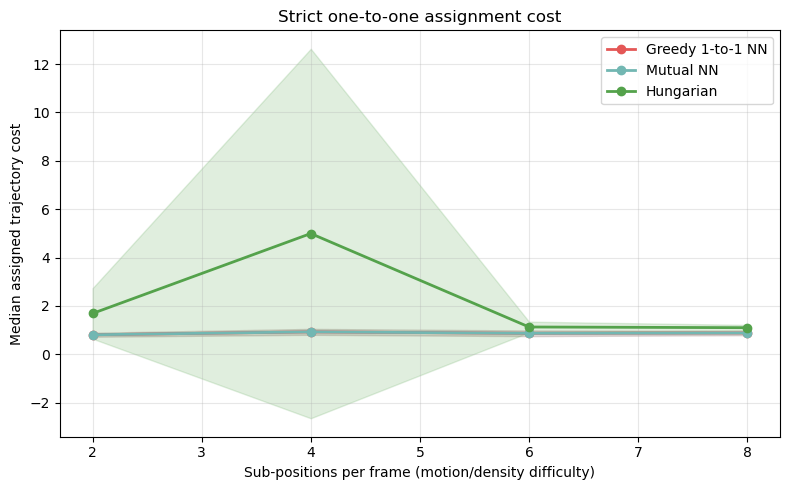

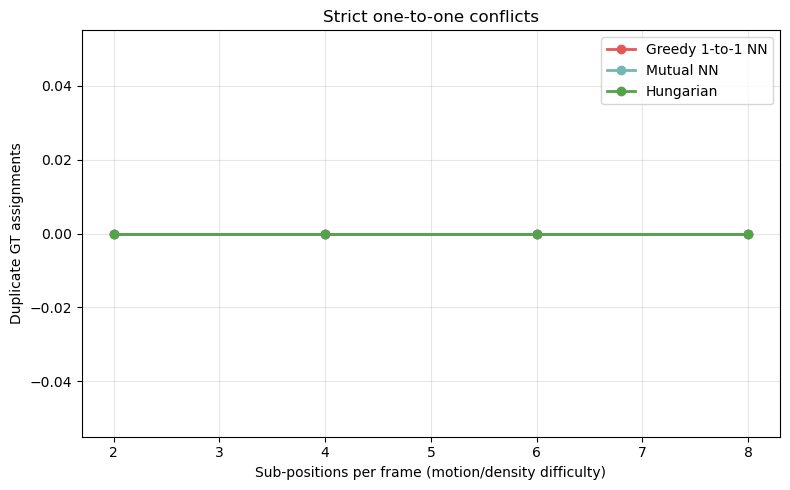

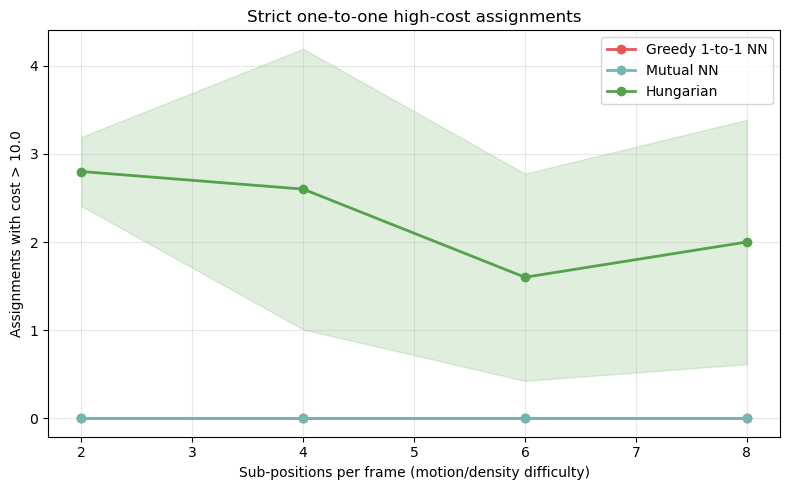

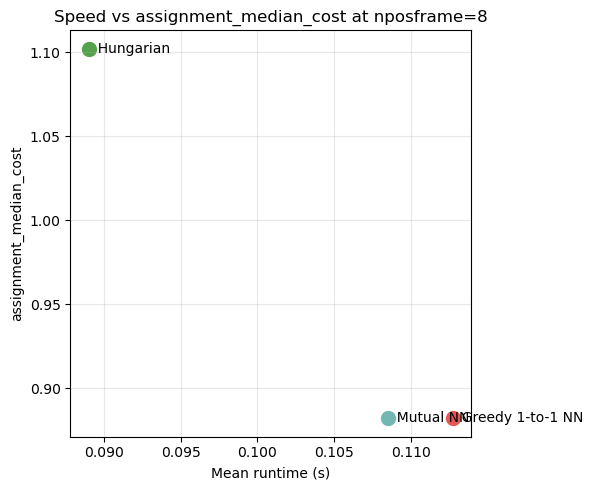

Mean paired assignment-cost delta against Hungarian. Negative means lower cost than Hungarian on the same simulation.


greedy_nn_minus_hungarian   -1.3561
mutual_nn_minus_hungarian   -1.3561
dtype: float64

Mean paired Link-F1 delta against Hungarian. Positive means higher link F1 than Hungarian on the same simulation.


greedy_nn_minus_hungarian   -0.0696
mutual_nn_minus_hungarian   -0.0696
dtype: float64

In [14]:
strict_metrics = [
    "link_f1",
    "link_precision",
    "link_recall",
    "mean_coverage",
    "mean_fragments_per_gt",
    "median_position_error_px",
    "duplicate_gt_assignments",
    "high_cost_assignments",
    "assignment_mean_cost",
    "assignment_median_cost",
    "runtime_s",
]

strict_summary = summarize_metrics(
    strict_df,
    group_cols=["nposframe", "algo", "algo_label"],
    metrics=strict_metrics,
)

display(
    strict_df.pivot_table(
        index="nposframe",
        columns="algo_label",
        values="link_f1",
        aggfunc="mean",
    ).round(3)
)

display(
    strict_df.pivot_table(
        index="nposframe",
        columns="algo_label",
        values="assignment_median_cost",
        aggfunc="mean",
    ).round(3)
)

display(
    strict_summary.sort_values(["nposframe", "algo"])
    .round(4)
    .reset_index(drop=True)
)

plot_metric_vs_density(
    strict_df,
    "link_f1",
    ylabel="Link F1",
    title="Strict one-to-one assignment robustness",
    ylim=(0, 1.02),
    methods=STRICT_METHODS,
)

plot_metric_vs_density(
    strict_df,
    "assignment_median_cost",
    ylabel="Median assigned trajectory cost",
    title="Strict one-to-one assignment cost",
    methods=STRICT_METHODS,
)

plot_metric_vs_density(
    strict_df,
    "duplicate_gt_assignments",
    ylabel="Duplicate GT assignments",
    title="Strict one-to-one conflicts",
    methods=STRICT_METHODS,
)

plot_metric_vs_density(
    strict_df,
    "high_cost_assignments",
    ylabel=f"Assignments with cost > {ASSIGNMENT_COST_LIMIT}",
    title="Strict one-to-one high-cost assignments",
    methods=STRICT_METHODS,
)

plot_speed_accuracy(strict_df, metric="assignment_median_cost", methods=STRICT_METHODS)

strict_cost_delta = paired_delta_table(
    strict_df,
    "assignment_median_cost",
    baseline="hungarian",
    methods=STRICT_METHODS,
)
strict_f1_delta = paired_delta_table(
    strict_df,
    "link_f1",
    baseline="hungarian",
    methods=STRICT_METHODS,
)

print("Mean paired assignment-cost delta against Hungarian. Negative means lower cost than Hungarian on the same simulation.")
display(strict_cost_delta.drop(columns=["seed", "nposframe", "poisson_noise"]).mean().round(4))

print("Mean paired Link-F1 delta against Hungarian. Positive means higher link F1 than Hungarian on the same simulation.")
display(strict_f1_delta.drop(columns=["seed", "nposframe", "poisson_noise"]).mean().round(4))


How to read these figures: Hungarian should be the reference point for lowest total cost under the one-to-one constraint. Greedy NN is the simplest strict baseline but is order-sensitive. Mutual NN is more conservative and usually leaves more pairs unassigned. If Hungarian beats both on cost while keeping comparable link F1, that is the strongest argument for using it in this experiment.


## 4. Composite figure from saved panel outputs

This builds a publication-style multi-panel figure directly from the PNG outputs already stored in this notebook. No benchmark recomputation is performed.


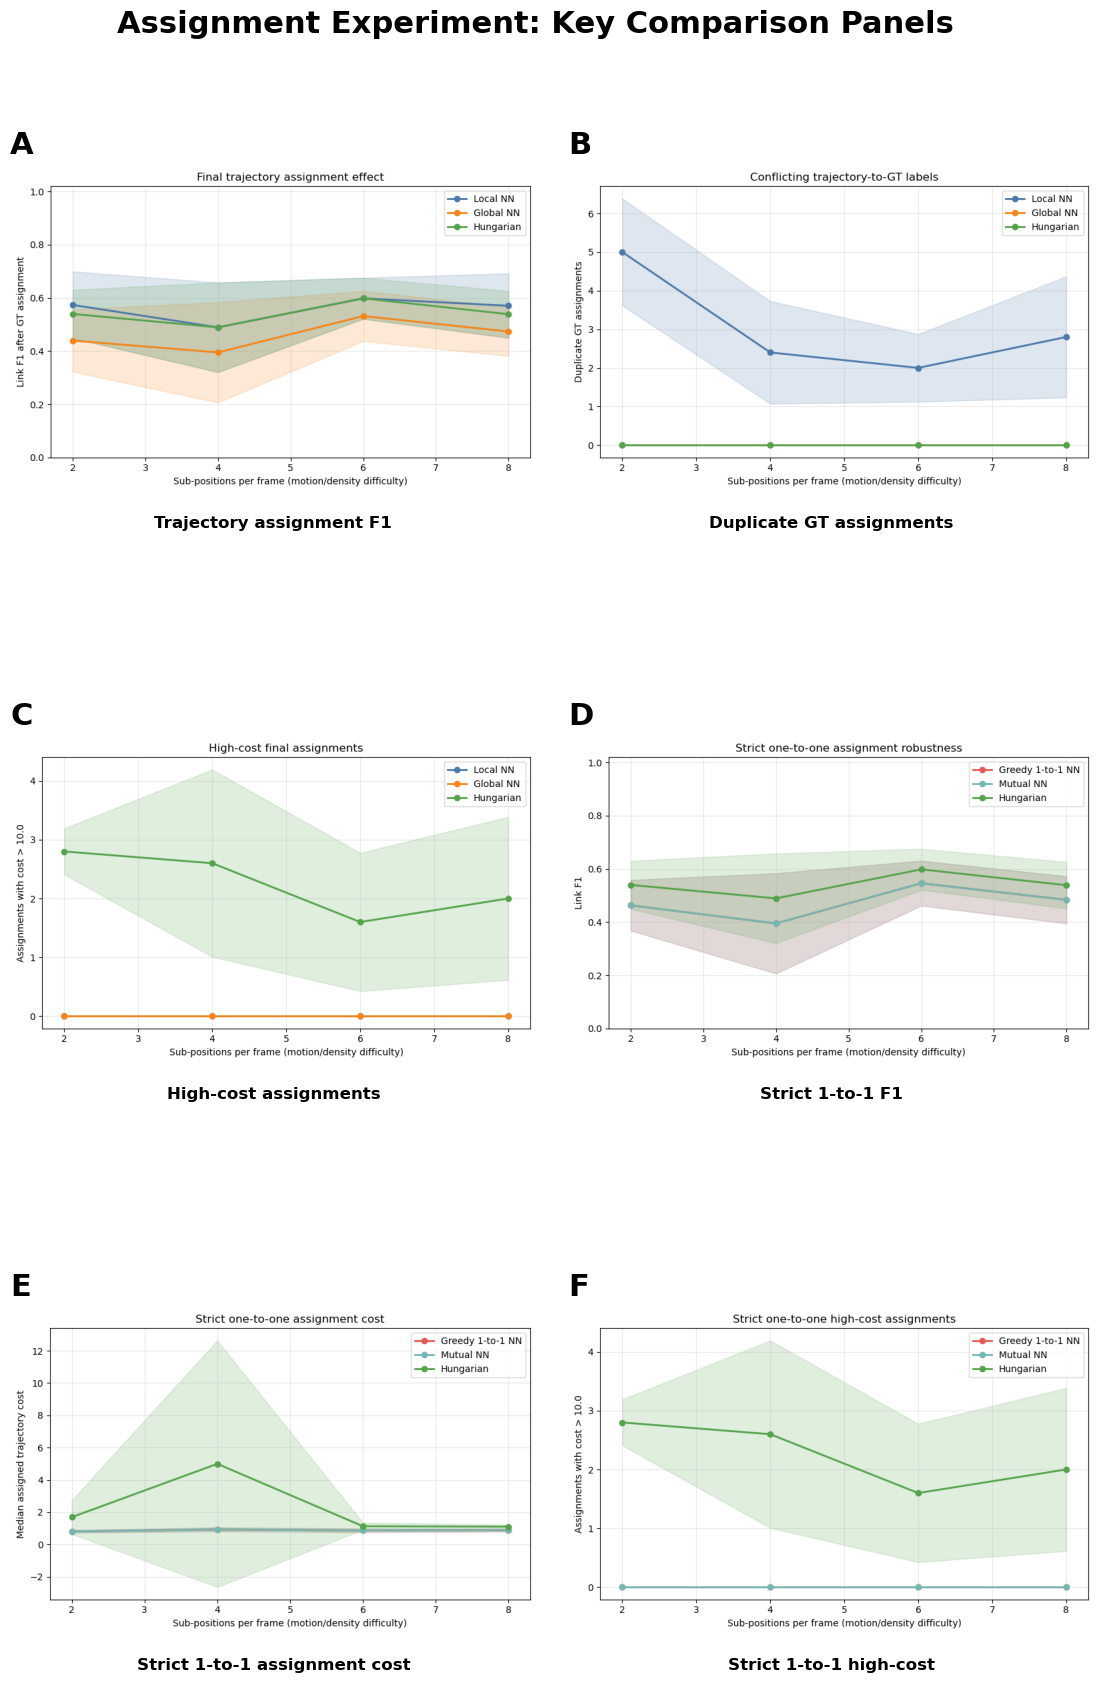

Saved composite figure:
- Experiments\AssignmentExperiment2_key_panels.png
- Experiments\AssignmentExperiment2_key_panels.pdf


In [17]:
import base64
import io
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def _cell_png_outputs_by_index(nb_dict, one_based_cell_index):
    cells = nb_dict.get("cells", [])
    if one_based_cell_index < 1 or one_based_cell_index > len(cells):
        return []
    cell = cells[one_based_cell_index - 1]
    images = []
    for out in cell.get("outputs", []):
        data = out.get("data", {}) if isinstance(out, dict) else {}
        png_data = data.get("image/png")
        if png_data is None:
            continue
        png_b64 = "".join(png_data) if isinstance(png_data, list) else png_data
        images.append(base64.b64decode(png_b64))
    return images


nb_path = Path("Experiments/AssignmentExperiment2.ipynb")
with nb_path.open("r", encoding="utf-8") as f:
    nb_json = json.load(f)

# Use fixed cell positions that contain already-rendered figures in this notebook version.
# Cell 19: trajectory-to-GT comparison plots (4 PNG outputs)
# Cell 23: strict one-to-one comparison plots (5 PNG outputs)
assignment_images = _cell_png_outputs_by_index(nb_json, 19)
strict_images = _cell_png_outputs_by_index(nb_json, 23)

if len(assignment_images) < 3 or len(strict_images) < 4:
    raise RuntimeError(
        "Not enough saved PNG outputs found in cells 19 and 23. "
        "Please rerun those plotting cells once so outputs are stored in the notebook."
    )

panel_specs = [
    ("A", "Trajectory assignment F1", assignment_images[0]),
    ("B", "Duplicate GT assignments", assignment_images[1]),
    ("C", "High-cost assignments", assignment_images[2]),
    ("D", "Strict 1-to-1 F1", strict_images[0]),
    ("E", "Strict 1-to-1 assignment cost", strict_images[1]),
    ("F", "Strict 1-to-1 high-cost", strict_images[3]),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.subplots_adjust(top=0.93, bottom=0.04, hspace=0.24, wspace=0.06)

for ax, (letter, title, img_bytes) in zip(axes.flat, panel_specs):
    img = mpimg.imread(io.BytesIO(img_bytes), format="png")
    ax.imshow(img)
    ax.axis("off")

    # Put panel letter outside image content to avoid title overlap.
    ax.text(
        0.0,
        1.02,
        letter,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=22,
        fontweight="bold",
        color="black",
    )

    # Put panel caption below image, not over the original plot title.
    ax.text(
        0.5,
        -0.07,
        title,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12,
        fontweight="semibold",
        color="black",
        clip_on=False,
    )

out_dir = Path("Experiments")
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "AssignmentExperiment2_key_panels.png"
out_pdf = out_dir / "AssignmentExperiment2_key_panels.pdf"

fig.suptitle("Assignment Experiment: Key Comparison Panels", fontsize=22, fontweight="bold")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Saved composite figure:\n- {out_png}\n- {out_pdf}")
